In [ ]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

os.chdir(r'c:\Repositories\asphalt-db')
#swithc working directory to 
from src.db_builder.models import *
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')

In [2]:
#connect to database using sqlite3/pands

conn = sqlite3.connect(working_dir.joinpath('asfalt_db_v1.sqlite'))

In [3]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)



,name
0,project
1,dijk
2,projectdijk
3,borehole
4,sample
5,test
6,bezwijksterkteruwe
7,bezwijksterkteprocessed
8,bezwijksterktesummary
9,generaldata


In [21]:

query = """
SELECT 
    b.id AS borehole_id,
    b.project_dijk_id AS project_dike_id,
    b.aanlegjaar AS construction_year,
    b.onderzoeksjaar AS investigation_year,
    pd.project_id AS project_id,
    pd.dijk_id AS dike_id,
    p.project_name AS project_name,
    d.dike_name AS dike_name,
    d.waterboard as waterboard
FROM Borehole b
JOIN ProjectDijk pd ON b.project_dijk_id = pd.id
JOIN Project p ON pd.project_id = p.id
JOIN DIJK d ON pd.dijk_id = d.id
"""


# Read into a pandas DataFrame
dikes_and_projects = pd.read_sql(query, conn)
dikes_and_projects['age_at_investigation'] = dikes_and_projects['investigation_year'] - dikes_and_projects['construction_year']

dikes_and_projects.head()
# dikes_and_projects.columns

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22


In [ ]:
# #load the BezwijksterkteSummary table (all columns) and connect to Test, Sample and Borehole to get the corresponding Borehole

query = """
SELECT 
    b.id AS borehole_id,
    s.id AS sample_id,
    s.sample_name AS sample_name,
    t.test_name AS test_name,
    g.HR AS HR,
    bzs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN GeneralData g ON s.id = g.sample_id
JOIN BezwijksterkteSummary bzs ON bzs.test_id = t.id
"""
df_bzs = pd.read_sql(query, conn)

#drop HR column because it has only 0's
df_bzs = df_bzs.drop_duplicates(subset=['sample_id', 'test_name'], keep='first')

df_bzs.sort_values('borehole_id').head()



,borehole_id,sample_id,sample_name,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
0,1,1,k1-b1,T_k1-b1,1,1,k1-b1,0.140012,845.411263,682.612478,469.888848,6.259762,13307.685104,1220.385972,0.091705,0.014650,0.289319
1,2,4,k2-b1,T_k2-b1,2,4,k2-b1,0.096297,1212.461276,772.955418,535.381092,5.381163,10049.202919,790.309841,0.078644,0.014615,0.294647
2,3,7,k3-b1,T_k3-b1,3,7,k3-b1,0.082952,937.031495,579.948853,352.859425,4.876932,13780.406940,1056.284704,0.076651,0.015717,0.381887
3,4,10,k4-b1,T_k4-b1,4,10,k4-b1,0.083127,1180.725811,828.712848,537.120868,6.708308,12456.420151,1309.306443,0.105111,0.015669,0.371331
4,5,13,k5-b1,T_k5-b1,5,13,k5-b1,0.083283,955.572918,500.039983,289.317153,4.720396,16308.786975,1308.015356,0.080203,0.016991,0.501078


In [ ]:
#do the same for VermoeiingSummary
query = """
SELECT
    b.id AS borehole_id,
    g.sample_id AS sample_id,
    s.sample_name AS sample_name,
    t.test_name AS test_name,
    vs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN GeneralData g ON s.id = g.sample_id
JOIN VermoeiingSummary vs ON vs.test_id = t.id

"""

df_vs = pd.read_sql(query, conn)
#drop duplicate rows based on sample_id and test_name and ensure that dropped duplicates have the same values in all columns
df_vs = df_vs.drop_duplicates(subset=['sample_id', 'test_name'], keep='first')
df_vs.drop(columns=['id'], inplace=True)
df_vs.head()

,borehole_id,sample_id,HR,sample_name,test_name,test_id,sample_name,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat
0,1,2,3.708333,K1-b2,T_K1-b2,2,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490
3,2,5,3.041667,K2-b2b,T_K2-b2b,5,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000
6,3,8,5.208333,K3-b2b,T_K3-b2b,8,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000
9,4,11,4.708333,K4-b2,T_K4-b2,11,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000
12,5,14,4.708333,K5-b2b,T_K5-b2b,14,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500


In [82]:
#join df_bzs to dikes_and_projects on borehole_id
df_merge_1 = pd.merge(dikes_and_projects, df_bzs, on='borehole_id', how='left',suffixes=('_dike', '_bzs'))
df_merge_1.head()

#join df_vs to df_merge_1 on borehole_id
df_final = pd.merge(df_merge_1, df_vs, on='borehole_id', how='left', suffixes=('_bzs', '_vs'))
df_final.head()

#add column of HR-categories
def categorize_hr(hr):
    if hr < 3:
        return 'HR <3%'
    elif 3 <= hr < 6:
        return 'HR 3-6%'
    elif 6 <= hr < 9:
        return 'HR 6-9%'
    else:
        return 'HR >9%'
df_final['HR_category'] = df_final['HR'].apply(categorize_hr)

In [83]:
columns = ['v','Sec_10', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'pha_50', 'sig_cyc', 'E_50', 'N_fat','age_at_investigation']
# sns.pairplot(df_merged, vars=columns, hue='HR_category')
for col in columns:
    fig, ax = plt.subplots()
    sns.histplot(data=df_final, x=col, hue='HR_category', kde=True, ax=ax)
    ax.set_title(f'Distribution of {col} by HR Category')
    plt.savefig(working_dir.joinpath(f'{col}_distribution_by_HR_category.png'))
    plt.close()

<Axes: xlabel='G_c', ylabel='sig_b'>

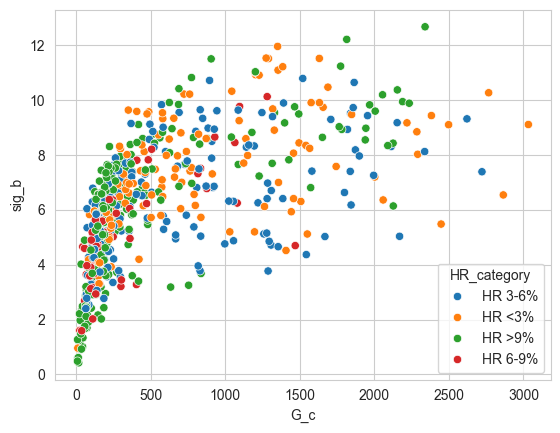

In [84]:
#scatterplot of v and sig_b
sns.scatterplot(data=df_final, x='G_c', y='sig_b', hue='HR_category')


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

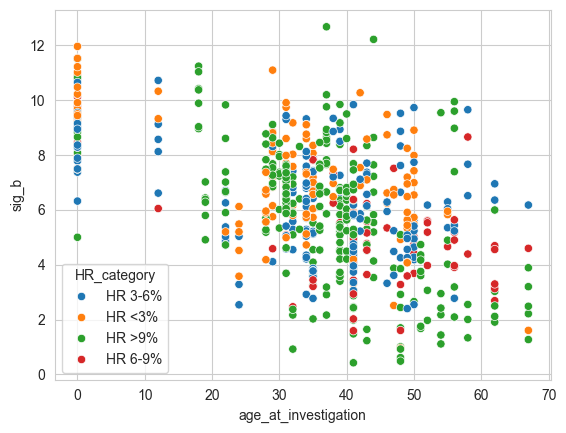

In [85]:
#scatterplot of age_at_investigation and sig_b
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR_category')

In [86]:
df_final.to_csv(working_dir.joinpath('Dikes_Projects_Samples_Tests.csv'), index=False)

In [87]:
#count nan rows in df_bzs
df_vs.isna().sum()


borehole_id    0
sample_id      0
HR             0
sample_name    0
test_name      0
test_id        0
sample_name    0
pha_ini        0
pha_50         0
sig_cyc        0
sig_perm       0
E_ini          0
E_50           0
N_fat          0
dtype: int64

In [184]:
#make new df, grouped by project_id with mean and std for 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'HR_category```

data_per_dike_project = pd.DataFrame.groupby(df_final, by='project_dike_id').agg({
    'v': ['mean', 'std'],
    'Sec_10': ['mean', 'std'],
    'Sec_50': ['mean', 'std'],
    'Sec_100': ['mean', 'std'], 
    'sig_b': ['mean', 'std'],
    'eps_b': ['mean', 'std'],
    'G_c': ['mean', 'std'],
    'G_c_over_eps_b': ['mean', 'std'],
    'G_c_over_eps_b_sig_b': ['mean', 'std'],
    'V_Ber': ['mean', 'std'],
    'pha_ini': ['mean', 'std'],
    'pha_50': ['mean', 'std'],
    'sig_cyc': ['mean', 'std'],
    'sig_perm': ['mean', 'std'],
    'E_ini': ['mean', 'std'],
    'E_50': ['mean', 'std'],
    'N_fat': ['mean', 'std'],
    'HR': ['mean', 'std']
})

#flatten multiindex columns
data_per_dike_project.columns = ['_'.join(col).strip() for col in data_per_dike_project.columns.values]

#for each parameter make a cov column based on mean and std
for col in data_per_dike_project.columns:
    if '_mean' in col:
        param = col.replace('_mean', '')
        data_per_dike_project[f'{param}_cov'] = data_per_dike_project[f'{param}_std'] / data_per_dike_project[col]
        
data_per_dike_project.head()



,v_mean,v_std,Sec_10_mean,Sec_10_std,Sec_50_mean,Sec_50_std,Sec_100_mean,Sec_100_std,sig_b_mean,sig_b_std,...,G_c_over_eps_b_sig_b_cov,V_Ber_cov,pha_ini_cov,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov
project_dike_id,,,,,,,,,,,,,,,,,,,,,
1,0.093844,0.019691,952.185074,180.853928,599.677180,153.574214,385.040331,115.299052,5.379182,0.722684,...,0.050732,0.182109,0.095103,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259
2,0.348080,0.002700,913.580442,680.084374,970.651078,570.635936,743.028048,383.067598,5.285134,3.437769,...,0.094955,0.731564,0.237534,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842
3,0.386370,0.006486,1732.259664,703.274649,1308.739884,778.494279,915.028036,663.367396,5.914768,2.463763,...,0.101024,0.393429,0.316625,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492
4,0.368810,0.007970,2070.112815,896.167977,1236.164396,313.462115,799.807418,246.789354,6.150636,1.059072,...,0.047307,0.172058,0.119420,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297
5,0.377687,0.009828,4671.261950,2502.235735,3205.788647,2432.940100,2386.385606,1777.040035,6.726597,1.750334,...,0.187447,0.764546,0.259881,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560


In [189]:
# subdir = working_dir.joinpath('per_dike_project_scatterplots')
# os.makedirs(subdir, exist_ok=True)
# for col1 in data_per_dike_project.columns:
#     for col2 in data_per_dike_project.columns:
#         if col1 != col2 and '_mean' in col1 and '_mean' in col2:
#             fig, ax = plt.subplots(ncols=2, figsize=(10,5))
#             sns.scatterplot(data=data_per_dike_project, x=col1, y=col2, ax=ax[0])
#             ax[0].set_xlabel(col1)
#             ax[0].set_ylabel(col2)
#             #same but then for _cov
#             param1 = col1.replace('_mean', '')
#             param2 = col2.replace('_mean', '')
#             sns.scatterplot(data=data_per_dike_project, x=f'{param1}_cov', y=f'{param2}_cov', ax=ax[1])
#             ax[1].set_xlabel(f'{param1}_cov')
#             ax[1].set_ylabel(f'{param2}_cov')
#             plt.suptitle(f'{col1} vs {col2} - scatterplot of mean and cov')

#             plt.savefig(subdir.joinpath(f'{col1}_vs_{col2}_scatter.png'))
#             plt.close()



In [195]:
#take unique for project_dike_id in dikes_and_projects
unique_dike_projects = dikes_and_projects.drop_duplicates(subset=['project_dike_id'])

data_per_dike_project = pd.merge(unique_dike_projects, data_per_dike_project, left_on='project_dike_id', right_index=True, how='right')
data_per_dike_project.reset_index(drop=True, inplace=True)
data_per_dike_project.head()

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov,HR_mean_category,HR_std_category,HR_cov_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259,HR 3-6%,medium,medium
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842,HR 6-9%,NaN,very high
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492,HR 3-6%,NaN,very high
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297,HR 3-6%,high,high
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560,HR 3-6%,high,high


In [196]:
#make categories for HR_mean
data_per_dike_project['HR_mean_category'] = data_per_dike_project.HR_mean.apply(categorize_hr)
#make categories for HR_std using pd cut
data_per_dike_project['HR_std_category'] = pd.cut(data_per_dike_project.HR_std, bins=[0, 0.5, 1, 1.5, 2], labels=['low', 'medium', 'high', 'very high'])
#and cov
data_per_dike_project['HR_cov_category'] = pd.cut(data_per_dike_project.HR_cov, bins=[0, 0.1, 0.3, 0.5, 1], labels=['low', 'medium', 'high', 'very high'])


In [197]:
data_per_dike_project

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov,HR_mean_category,HR_std_category,HR_cov_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259,HR 3-6%,medium,medium
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842,HR 6-9%,NaN,very high
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492,HR 3-6%,NaN,very high
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297,HR 3-6%,high,high
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560,HR 3-6%,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,959,81,1967,2018,32,79,P_1702837,pwn_spaarbekkens_-,PWN,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HR >9%,NaN,NaN
79,1047,82,1970,2019,33,80,P_1901142,eemshavendijk_,Groningen Seaports,49,...,0.389837,0.391199,0.374330,0.151688,0.133090,1.322344,0.495932,HR 3-6%,very high,high
80,1048,83,1970,2019,33,81,P_1901142,havendam_oost_(buitenzijde/zeezijde)_,Groningen Seaports,49,...,0.177573,0.303277,0.289884,0.143809,0.070640,1.211465,0.955066,HR <3%,very high,very high
81,1051,84,1970,2019,33,82,P_1901142,havendam_west_(buitenzijde/zeezijde)_,Groningen Seaports,49,...,0.255942,0.353111,0.330721,0.110516,0.126754,1.102713,0.690806,HR 3-6%,NaN,very high


<Axes: xlabel='age_at_investigation', ylabel='v_mean'>

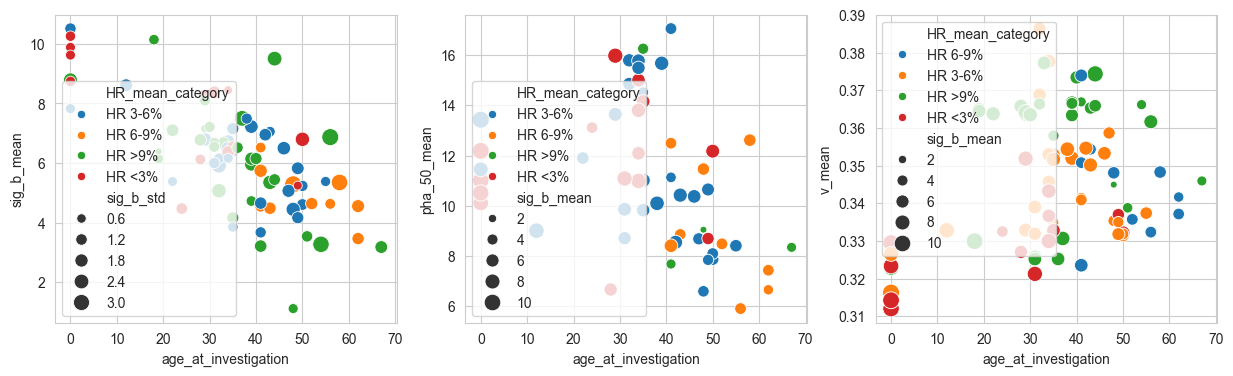

In [208]:
fig, ax = plt.subplots(figsize=(15,4), ncols=3)

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_mean_category', ax=ax[0], sizes=(25, 150), size = 'sig_b_std')
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='pha_50_mean', hue='HR_mean_category', ax=ax[1], sizes=(25, 150), size = 'sig_b_mean')
sns.scatterplot(data=data_per_dike_project.loc[data_per_dike_project.v_mean >0.25], x='age_at_investigation', y='v_mean', hue='HR_mean_category', ax=ax[2], sizes=(25, 150), size = 'sig_b_mean')


<Axes: xlabel='age_at_investigation', ylabel='sig_b_std'>

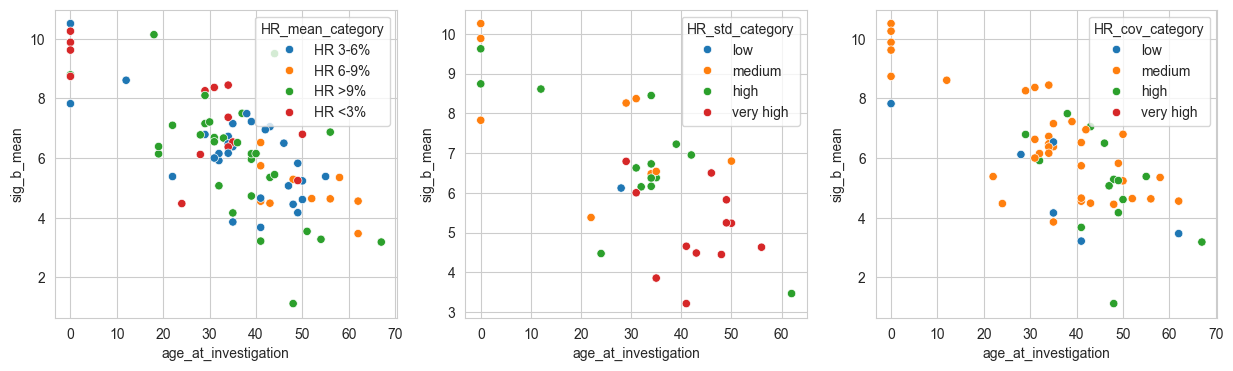

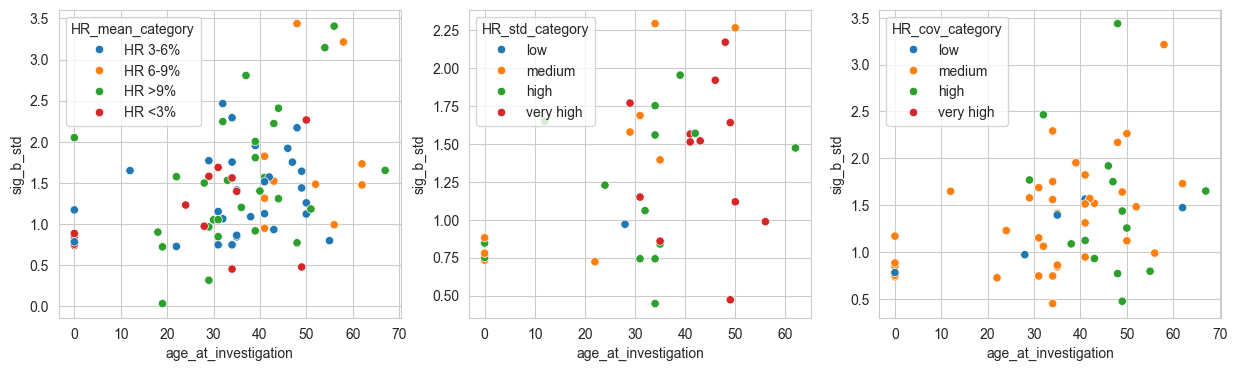

In [ ]:
#plot sig_b_mean and age_at_investigation
fig, ax = plt.subplots(figsize=(15,4), ncols=3)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_mean_category', ax=ax[0])

#same with std as hue
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_std_category', ax=ax[1])

#and cov as hue
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_cov_category', ax=ax[2])

fig,ax = plt.subplots(figsize=(15,4), ncols=3)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_mean_category', ax=ax[0])

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_std_category', ax=ax[1])

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_cov_category', ax=ax[2])

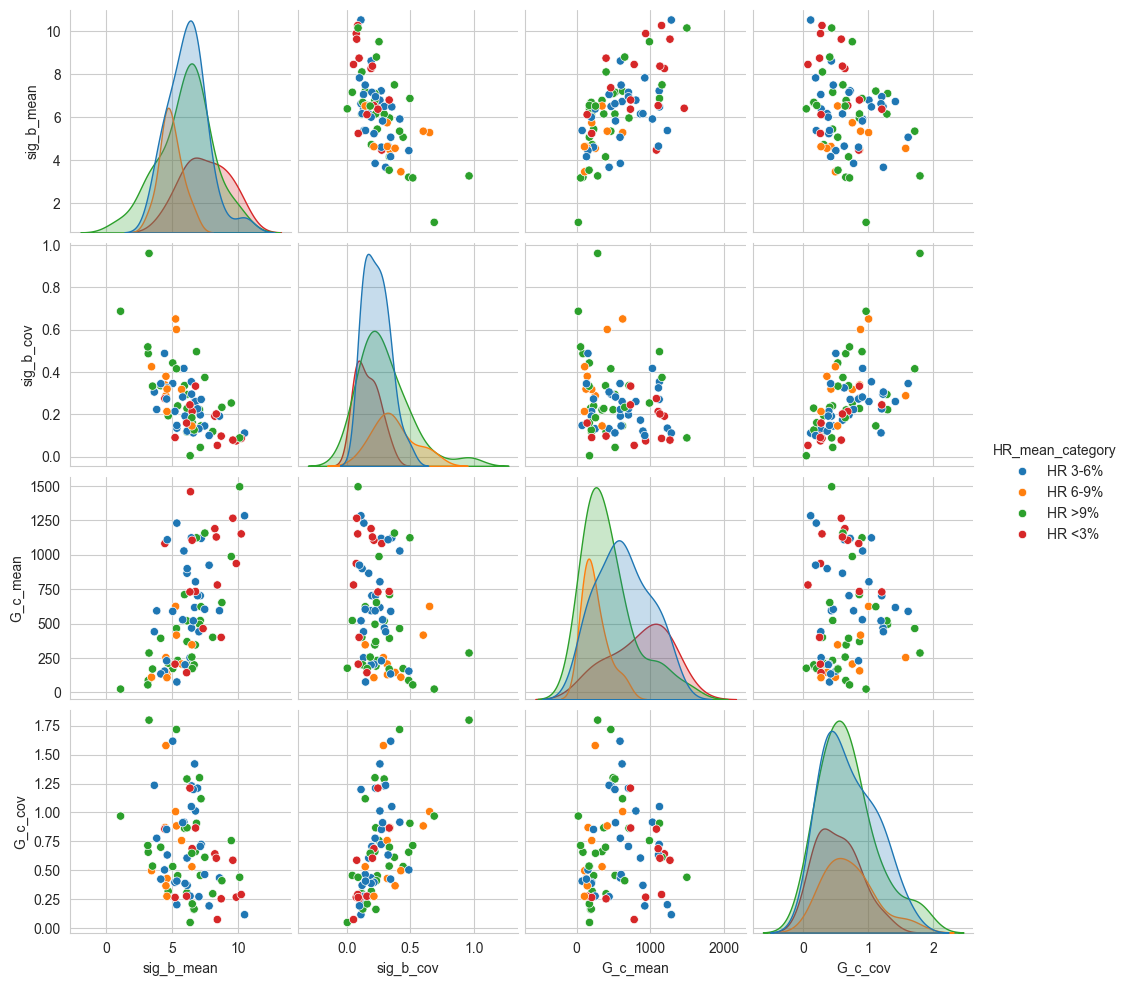

In [148]:
#correlation plots for sig_b mean, std and HR mean, std
sns.pairplot(data_per_dike_project, vars=['sig_b_mean', 'sig_b_cov', 'G_c_mean', 'G_c_cov'], hue = 'HR_mean_category')

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_43020\2932064084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_final, x='project_dike_id', y='HR', jitter=True, palette='Set2')


<Axes: xlabel='project_dike_id', ylabel='HR'>

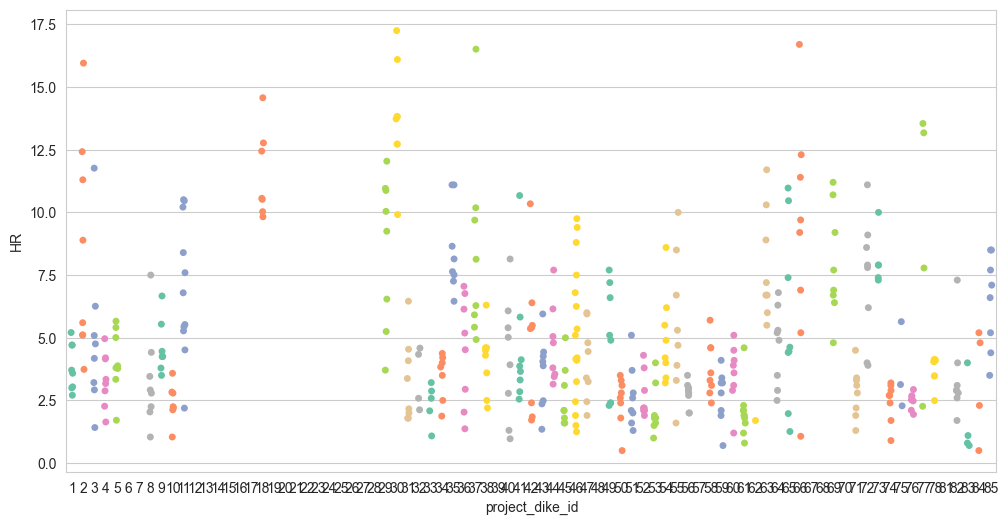

In [228]:
#make a violinplot of HR per project_dike_id 
plt.figure(figsize=(12,6))
sns.stripplot(data=df_final, x='project_dike_id', y='HR', jitter=True, palette='Set2')

<Axes: xlabel='construction_year', ylabel='HR_cov'>

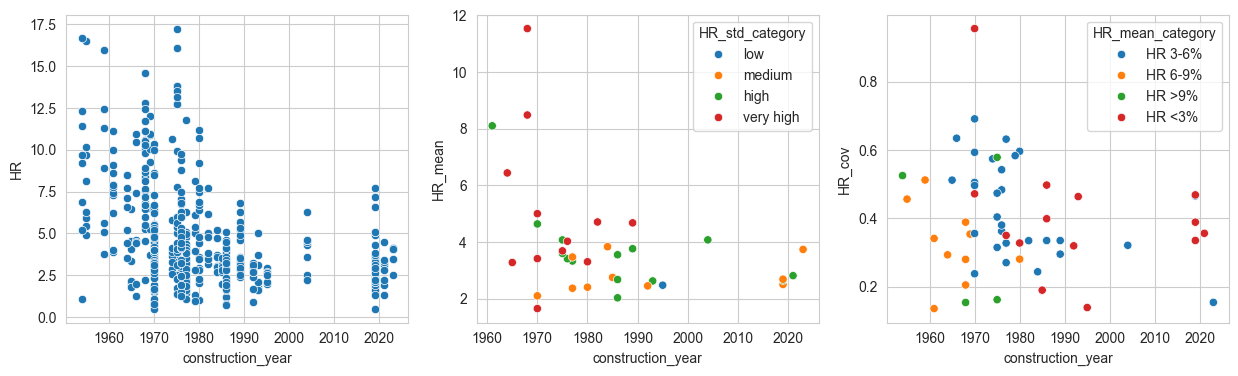

In [231]:
fig, ax = plt.subplots(figsize=(15,4), ncols = 3)
#scatterplot of construction_year vs HR
sns.scatterplot(data=df_final, x='construction_year', y='HR', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='construction_year', y='HR_mean', hue = 'HR_std_category', ax=ax[1])
sns.scatterplot(data=data_per_dike_project, x='construction_year', y='HR_cov', hue = 'HR_mean_category', ax=ax[2])

<Axes: xlabel='age_at_investigation', ylabel='sig_b_std'>

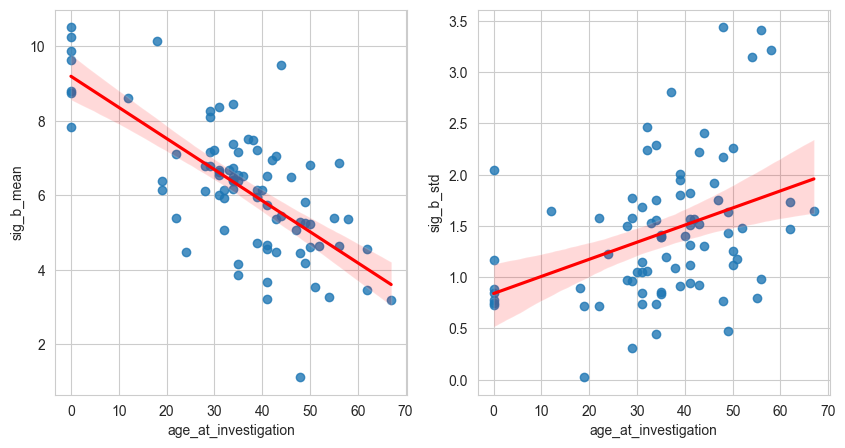

In [227]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

sns.regplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', scatter=True, ax=ax[0], x_ci='ci', ci=95, line_kws={'color': 'red'})
sns.regplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', scatter=True, ax=ax[1], x_ci='ci', ci=95, line_kws={'color': 'red'})

<Axes: xlabel='age_at_investigation', ylabel='G_c_cov'>

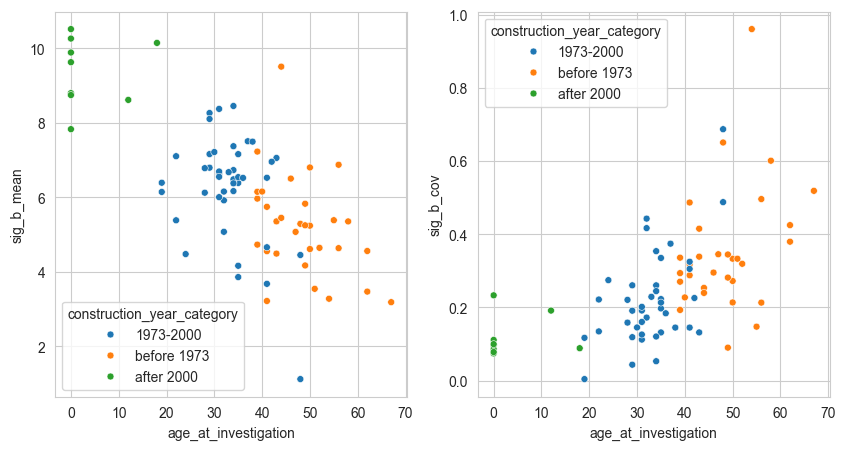

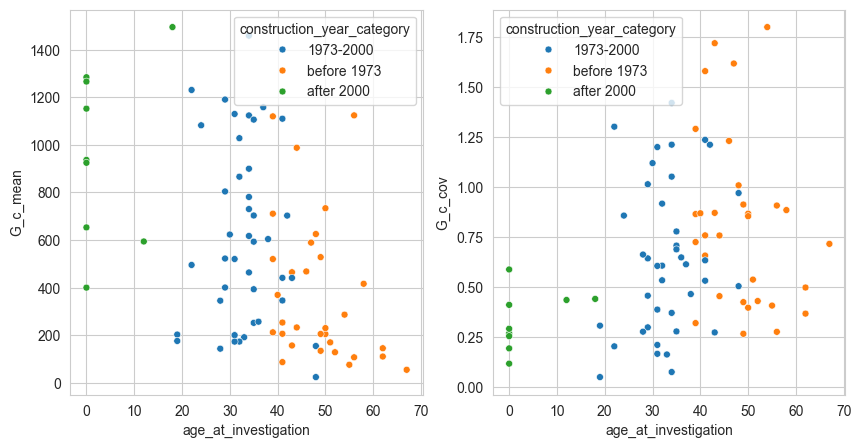

In [260]:
#alles van voor 1973: raus
#construction categories before 1973, between 1973 and 2000 and after 2000
def categorize_annum(year):
    if year < 1973:
        return 'before 1973'
    elif 1973 <= year < 2000:
        return '1973-2000'
    else:
        return 'after 2000'
data_per_dike_project['construction_year_category'] = data_per_dike_project.construction_year.apply(categorize_annum)

fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='construction_year_category', ax=ax[0], s=25)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_cov', hue='construction_year_category', ax=ax[1], s=25)

fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_mean', hue='construction_year_category', ax=ax[0], s=25)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_cov', hue='construction_year_category', ax=ax[1], s=25)


<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

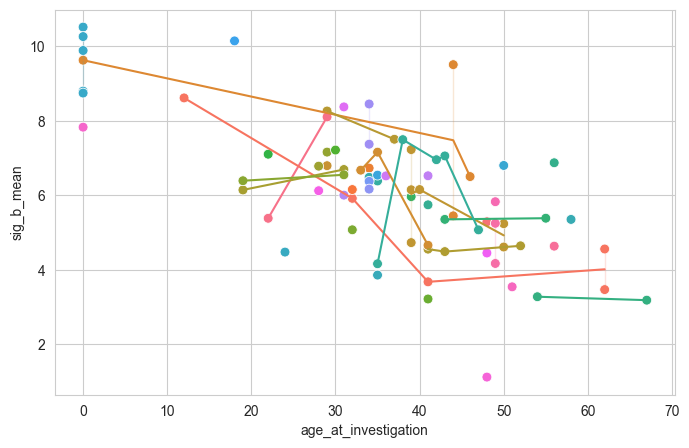

In [245]:
hoofddijk = data_per_dike_project.dike_name.apply(lambda x: x.split('_')[0])
data_per_dike_project['hoofddijk'] = hoofddijk

fig,ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='hoofddijk', s=50, ax=ax, legend = False)
sns.lineplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='hoofddijk',markers=True,ax=ax, legend= False)

<Axes: xlabel='age_at_investigation', ylabel='eps_b'>

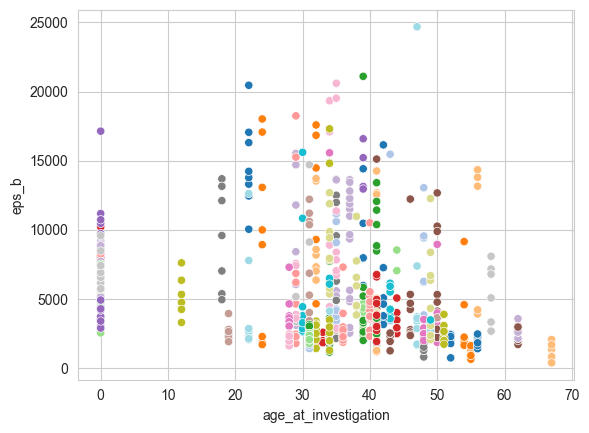

In [261]:
sns.scatterplot(data=df_final, x='age_at_investigation', y='eps_b',hue = 'dike_id', palette='tab20',legend=False)

<Axes: xlabel='sig_b', ylabel='eps_b'>

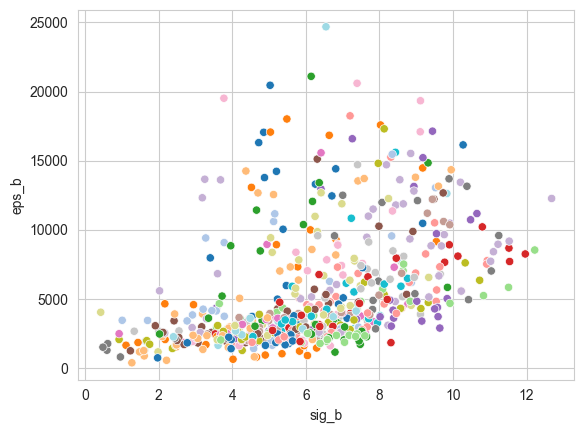

In [262]:
sns.scatterplot(data=df_final, x='sig_b', y='eps_b',hue = 'dike_id', palette='tab20',legend=False)

<Axes: xlabel='sig_b', ylabel='eps_b'>

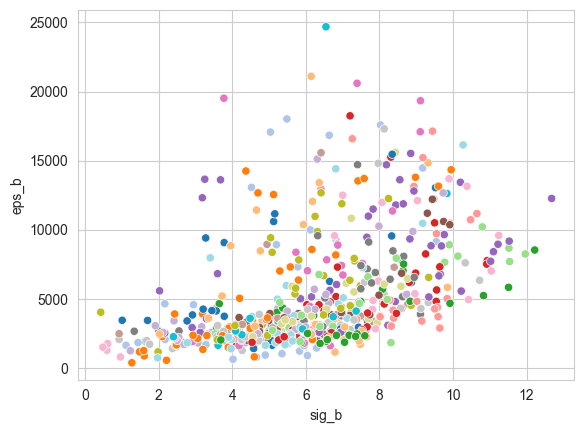

In [266]:
sns.scatterplot(data=df_final.loc[df_final.v>.25], x='sig_b', y='eps_b',hue = 'dike_id', palette='tab20',legend=False)